# 01 - So sánh trước và sau tiền xử lý

Notebook này so sánh raw train split với cleaned train split theo contract mới: raw giữ đầy đủ cột để thực nghiệm, còn clean chỉ giữ `review_id`, `content` và các nhãn multi-task.


In [1]:
from pathlib import Path
import json

from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "inline")
    except Exception:
        plt.switch_backend("Agg")
else:
    plt.switch_backend("Agg")

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

SENTIMENT_MAP = {0: "Tieu cuc", 1: "Trung lap", 2: "Tich cuc"}
SENTIMENT_COLORS = {0: "#d64b4b", 1: "#f0ad4e", 2: "#2ca02c"}
SENTIMENT_ORDER = [0, 1, 2]
STAGE_ORDER = ["raw", "clean"]
STAGE_COLORS = {"raw": "#7aa6ff", "clean": "#2d6cdf"}


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root")


def style_axes(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color="#dfe3eb", linewidth=0.8, alpha=0.9)
    sns.despine(ax=ax)


def add_bar_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)


ROOT = find_project_root()
RAW_TRAIN = ROOT / "data/interim/raw_train/train.json"
CLEAN_TRAIN = ROOT / "data/processed/train_clean.json"
RAW_SCAN = ROOT / "experiments/reports/train_scan.json"
CLEAN_SCAN = ROOT / "experiments/reports/train_clean_scan.json"

raw_df = pd.read_json(RAW_TRAIN)
clean_df = pd.read_json(CLEAN_TRAIN)
raw_report = json.loads(RAW_SCAN.read_text(encoding="utf-8"))
clean_report = json.loads(CLEAN_SCAN.read_text(encoding="utf-8"))

raw_lookup = raw_df[["review_id", "content", "product_name"]].rename(columns={"content": "content_raw"})
clean_aligned = clean_df.rename(columns={"content": "content_clean"}).merge(
    raw_lookup,
    on="review_id",
    how="left",
    validate="one_to_one",
)

print(f"raw rows: {len(raw_df)}")
print(f"clean rows: {len(clean_df)}")
print(f"rows removed: {len(raw_df) - len(clean_df)}")
print(f"clean columns: {list(clean_df.columns)}")


raw rows: 9392
clean rows: 9362
rows removed: 30
clean columns: ['review_id', 'content', 'sentiment_llm', 'as_content', 'as_physical', 'as_price', 'as_packaging', 'as_delivery', 'as_service']


In [2]:
def extract_metrics(report: dict) -> dict:
    checks = report["checks"]
    return {
        "rows": report["metadata"]["row_count"],
        "missing_content": checks["missing_values"]["per_column"]["content"]["missing_count"],
        "short_texts": checks["length"]["shorter_than_min_length"],
        "encoding_rows": checks["encoding"]["rows_with_any_issue"],
        "noise_rows": checks["noise_patterns"]["rows_with_any_noise"],
        "emoji_rows": checks["emoji"]["rows_with_emoji"],
        "duplicates": checks["duplicates"]["normalized_duplicate_texts"],
    }


summary = pd.DataFrame(
    [extract_metrics(raw_report), extract_metrics(clean_report)],
    index=["raw", "clean"],
).T
summary.loc["rows", "raw"] = len(raw_df)
summary.loc["rows", "clean"] = len(clean_df)

issue_df = pd.DataFrame(
    {
        "raw": [
            raw_report["checks"]["encoding"]["rows_with_any_issue"],
            raw_report["checks"]["noise_patterns"]["rows_with_any_noise"],
            raw_report["checks"]["emoji"]["rows_with_emoji"],
            raw_report["checks"]["duplicates"]["normalized_duplicate_texts"],
        ],
        "clean": [
            clean_report["checks"]["encoding"]["rows_with_any_issue"],
            clean_report["checks"]["noise_patterns"]["rows_with_any_noise"],
            clean_report["checks"]["emoji"]["rows_with_emoji"],
            clean_report["checks"]["duplicates"]["normalized_duplicate_texts"],
        ],
    },
    index=["encoding", "noise", "emoji", "duplicates"],
)
issue_long = issue_df.rename_axis("issue").reset_index().melt(id_vars="issue", var_name="stage", value_name="count")

label_before = raw_df["sentiment_llm"].value_counts().sort_index()
label_after = clean_df["sentiment_llm"].value_counts().sort_index()
label_compare = pd.DataFrame({"raw": label_before, "clean": label_after}).fillna(0).astype(int)
label_compare.index = label_compare.index.map(lambda idx: SENTIMENT_MAP.get(idx, str(idx)))
label_compare.index.name = "sentiment"
label_long = label_compare.reset_index().melt(id_vars="sentiment", var_name="stage", value_name="count")

raw_words = raw_df["content"].fillna("").str.split().map(len)
clean_words = clean_df["content"].fillna("").str.split().map(len)
length_long = pd.DataFrame({"raw": raw_words, "clean": clean_words}).melt(var_name="stage", value_name="words")


def build_changed_frame(df: pd.DataFrame) -> pd.DataFrame:
    changed = df.loc[df["content_raw"].fillna("") != df["content_clean"].fillna("")].copy()
    changed["sentiment_name"] = changed["sentiment_llm"].map(SENTIMENT_MAP).fillna(changed["sentiment_llm"].astype(str))
    changed["raw_len"] = changed["content_raw"].fillna("").str.len()
    changed["clean_len"] = changed["content_clean"].fillna("").str.len()
    changed["delta"] = changed["raw_len"] - changed["clean_len"]
    changed["word_delta"] = changed["content_raw"].fillna("").str.split().map(len) - changed["content_clean"].fillna("").str.split().map(len)
    return changed


changed = build_changed_frame(clean_aligned)

display(summary)
display(label_compare)


,raw,clean
rows,9392,9362
missing_content,6,0
short_texts,19,0
encoding_rows,194,23
noise_rows,699,593
emoji_rows,296,0
duplicates,17,2


,raw,clean
sentiment,,
Tieu cuc,4922,4909
Trung lap,1532,1526
Tich cuc,2938,2927


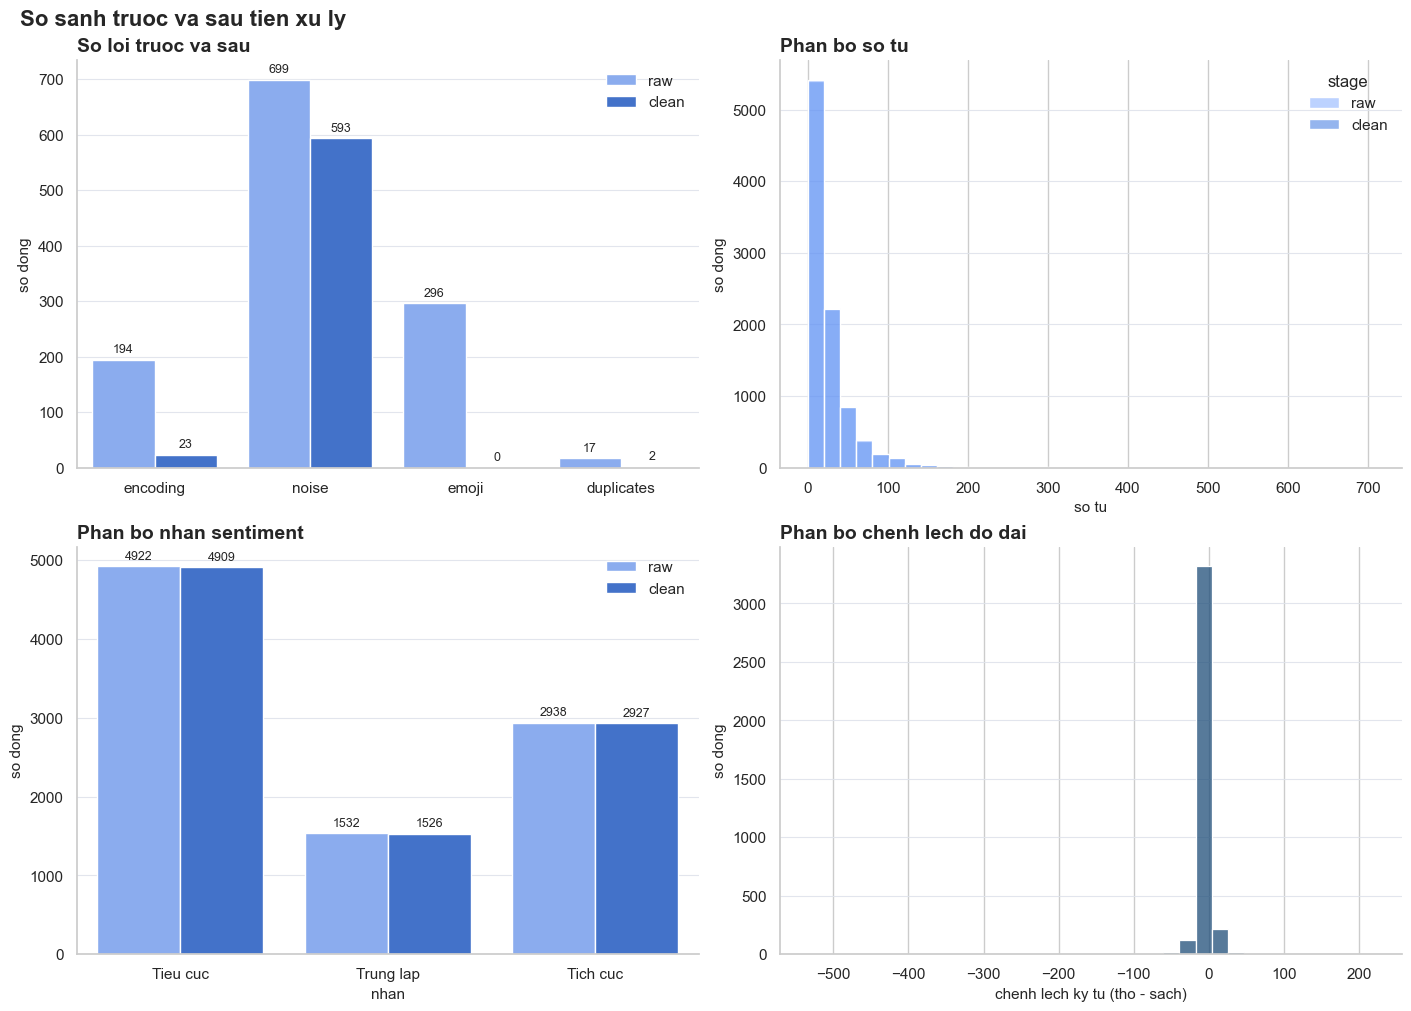

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle("So sanh truoc va sau tien xu ly", x=0.01, ha="left", fontsize=16, fontweight="bold")

ax = axes[0, 0]
sns.barplot(
    data=issue_long,
    x="issue",
    y="count",
    hue="stage",
    order=issue_df.index.tolist(),
    hue_order=STAGE_ORDER,
    palette=STAGE_COLORS,
    errorbar=None,
    ax=ax,
)
style_axes(ax)
ax.set_title("So loi truoc va sau", loc="left")
ax.set_xlabel("")
ax.set_ylabel("so dong")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(title=None, frameon=False)
add_bar_labels(ax)

ax = axes[0, 1]
sns.histplot(
    data=length_long,
    x="words",
    hue="stage",
    bins=35,
    stat="count",
    common_norm=False,
    multiple="layer",
    alpha=0.5,
    palette=STAGE_COLORS,
    ax=ax,
)
style_axes(ax)
ax.set_title("Phan bo so tu", loc="left")
ax.set_xlabel("so tu")
ax.set_ylabel("so dong")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(title=None, frameon=False)

ax = axes[1, 0]
sns.barplot(
    data=label_long,
    x="sentiment",
    y="count",
    hue="stage",
    order=list(SENTIMENT_MAP.values()),
    hue_order=STAGE_ORDER,
    palette=STAGE_COLORS,
    errorbar=None,
    ax=ax,
)
style_axes(ax)
ax.set_title("Phan bo nhan sentiment", loc="left")
ax.set_xlabel("nhan")
ax.set_ylabel("so dong")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(title=None, frameon=False)
add_bar_labels(ax)

ax = axes[1, 1]
sns.histplot(data=changed, x="delta", bins=35, color="#1f4e79", ax=ax)
style_axes(ax)
ax.set_title("Phan bo chenh lech do dai", loc="left")
ax.set_xlabel("chenh lech ky tu (tho - sach)")
ax.set_ylabel("so dong")

plt.show()


- Encoding (Mã hóa): Giảm mạnh từ 194 xuống còn 23 lỗi. Chứng tỏ module unicode_norm đã xử lý rất tốt các lỗi font chữ và mã hóa.
- Noise (Nhiễu): Giảm từ 699 xuống 593. Đây là kết quả của việc loại bỏ các thẻ HTML rác và thay thế URL/Email/SĐT.
- Emoji: Giảm từ 296 về đúng bằng 0. Điều này cực kỳ tốt, vì toàn bộ emoji đã được module emoji_norm chuyển ngữ sang tiếng Việt hoàn toàn.
- Duplicates (Trùng lặp): Giảm từ 17 xuống 2. Các nội dung lặp lại đã bị module quality_filter loại bỏ

,review_id,product_name,sentiment_name,raw_len,clean_len,delta,content_raw,content_clean
4068,12593634,Sách Sinh Học Phân Tử Của Tế Bào - Sự Sinh Trưởng Và Phát Triển Của Tế Bào (Tập 5),Trung lap,255,36,219,Sách được bao gói tốt. Tớ chưa đọc...................................................................................................,Sách được bao gói tốt. Tớ chưa đọc..
2466,12033310,Sách Payback Time - Ngày Đòi Nợ,Tich cuc,2091,1883,208,Đã đọc 1 lèo hết quyển sách. Thực ra mình mua quyển sách này sau khi biết đến a Thái Phạm và thật sự muốn cảm ơn a Thái vì những gì a ma...,Đã đọc 1 lèo hết quyển sách. Thực ra mình mua quyển sách này sau khi biết đến a Thái Phạm và thật sự muốn cảm ơn a Thái vì những gì a ma...
3828,10645258,Combo 2 Cuốn: How To Crack The IELTS Speaking +Writing Test,Tich cuc,1907,1710,197,"Nhìn chung, đây là bộ sách hay được đầu tư công phu về mặt thiết kế và nội dung. Sau 1 tuần sử dụng, mình nhận thấy có sự khác nhau khá ...","Nhìn chung, đây là bộ sách hay được đầu tư công phu về mặt thiết kế và nội dung. Sau 1 tuần sử dụng, mình nhận thấy có sự khác nhau khá ..."
7592,661001,Sách Tự Học Tiếng Nhật Dành Cho Người Mới Bắt Đầu (Kèm CD Hoặc Dùng App),Tieu cuc,212,69,143,Kêu có CD mà? Sao méo có!!! :V. Vậy sao không bỏ dòng kèm CD đi> :(((\nggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggg...,Kêu có cd mà? Sao méo có!! emoji_v_v_y_sao_kh_ng_b_d_ng_k_m_cd_i((( g
9038,9948743,Sách Muôn Kiếp Nhân Sinh 2,Trung lap,3185,3042,143,"(Quan điểm cá nhân)\n- Đánh giá nội dung: Khá\n- Loại sách: xếp vào loại sách tiểu thuyết với chất liệu lịch sử, luân hồi, nhân quả..., ...","(Quan điểm cá nhân) - Đánh giá nội dungemoji_kh_lo_i_s_ch xếp vào loại sách tiểu thuyết với chất liệu lịch sử, luân hồi, nhân quả.., sẽ ..."


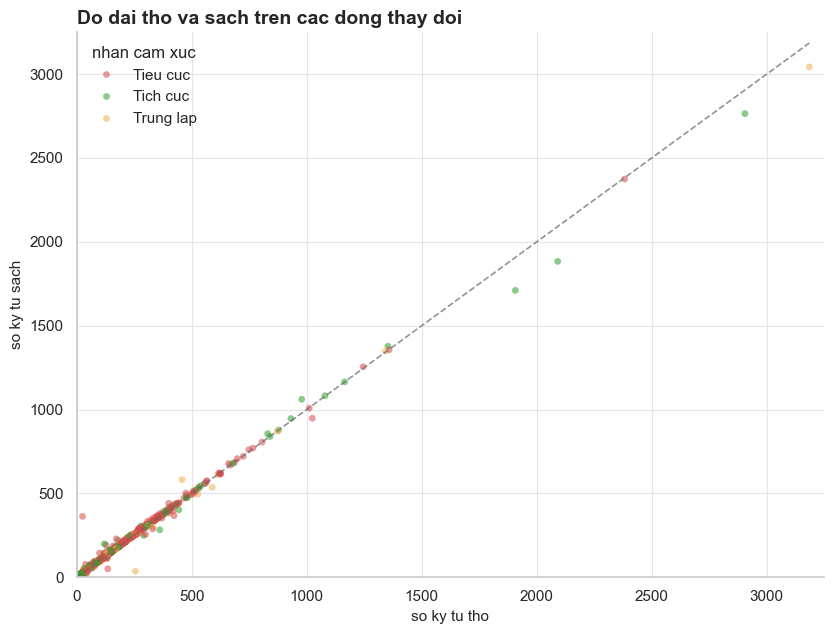

,product_name,rows,avg_delta,avg_words_delta
0,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),112,-4.080357,0.196429
1,Sách Hai Mặt Của Gia Đình,77,-3.311688,3.324675
2,Sách Barron's Essential Words For The Toeic (Tái Bản),53,-2.924528,1.735849
3,Combo Doraemon - Truyện Dài (Trọn Bộ 24 Cuốn) - Tái Bản,47,-1.042553,0.000000
4,Sách Sức Mạnh Tiềm Thức (Tái Bản) (Bìa Mềm),47,-7.468085,0.000000


In [4]:
top_changed = changed.sort_values("delta", ascending=False).head(5)
display(top_changed[["review_id", "product_name", "sentiment_name", "raw_len", "clean_len", "delta", "content_raw", "content_clean"]])

sample_changed = changed.sample(min(len(changed), 800), random_state=42) if not changed.empty else changed.copy()
fig, ax = plt.subplots(figsize=(8.5, 6.5))
if not sample_changed.empty:
    sns.scatterplot(
        data=sample_changed,
        x="raw_len",
        y="clean_len",
        hue="sentiment_name",
        palette={SENTIMENT_MAP[label]: SENTIMENT_COLORS[label] for label in SENTIMENT_ORDER},
        s=24,
        alpha=0.55,
        edgecolor="none",
        ax=ax,
    )

max_len = max(sample_changed["raw_len"].max(), sample_changed["clean_len"].max()) if not sample_changed.empty else 1
ax.plot([0, max_len], [0, max_len], linestyle="--", linewidth=1.2, color="#666666", alpha=0.7)
style_axes(ax, grid_axis="both")
ax.set_title("Do dai tho va sach tren cac dong thay doi", loc="left")
ax.set_xlabel("so ky tu tho")
ax.set_ylabel("so ky tu sach")
ax.set_xlim(0, max_len * 1.02 if max_len else 1)
ax.set_ylim(0, max_len * 1.02 if max_len else 1)
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(title="nhan cam xuc", frameon=False)
plt.tight_layout()
plt.show()

product_summary = (
    changed.groupby("product_name")
    .agg(rows=("review_id", "count"), avg_delta=("delta", "mean"), avg_words_delta=("word_delta", "mean"))
    .sort_values(["rows", "avg_delta"], ascending=[False, False])
    .head(5)
    .reset_index()
)
display(product_summary)


## Kết luận

- `content` được làm sạch mạnh phần kỹ thuật nhưng vẫn giữ tín hiệu sentiment cốt lỗi.
- Clean split hiện chỉ còn `review_id`, `content` và các nhãn multi-task, phù hợp trực tiếp cho huấn luyện.
- Raw split vẫn được giữ riêng để bạn tiếp tục thử các chiến lược preprocessing khác.
- `review_id` là khóa nối giúp đối chiếu raw/clean mà không cần giữ metadata dư thừa trong clean file.
